In [ ]:
!pip install -r requirements.txt

In [2]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoConfig, TrainingArguments, Trainer, BertModel, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pypinyin import pinyin, Style
import torch
import torch.nn as nn
import numpy as np
import evaluate
import pandas as pd
import os
import pronouncing

/opt/miniconda3/envs/Chinese_pun/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/Chinese_pun/lib/python3.12/site-packages/pronouncing/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


In [3]:
# ============================================================
# DEVICE CONFIGURATION - Set USE_GPU to True if GPU available
# ============================================================
import torch

USE_GPU = True  # Set to True if you have GPU (CUDA/MPS)

# Detect available device
if USE_GPU:
    if torch.cuda.is_available():
        device = "cuda"
        print("✅ GPU (CUDA) detected and enabled")
    elif torch.backends.mps.is_available():
        device = "mps"  # Mac with Apple Silicon
        print("✅ GPU (MPS) detected and enabled")
    else:
        device = "cpu"
        print("⚠️ GPU requested but not available, falling back to CPU")
else:
    device = "cpu"
    print("✅ Using CPU (set USE_GPU=True to enable GPU)")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device.upper()}")

✅ GPU (MPS) detected and enabled
PyTorch version: 2.10.0
Device: MPS


## Context Model

### Define Model

In [4]:
import torch.nn as nn
from transformers import BertModel, BertPreTrainedModel, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback, PreTrainedConfig


In [5]:
import torch
import torch.nn as nn
from transformers import BertModel

class ChineseBertToxicClassifier(nn.Module):
    def __init__(self, config, pinyin_vocab_size):
        super().__init__()
        self.config = config
        self.bert = BertModel.from_pretrained("bert-base-chinese", config=config)
        
        # Pinyin Embedding layer (Matches BERT hidden size)
        self.pinyin_embeddings = nn.Embedding(pinyin_vocab_size, config.hidden_size)
        
        # The Fusion Layer: Maps [Char_Embed + Pinyin_Embed] back to Hidden_Size
        self.fusion_layer = nn.Linear(config.hidden_size * 2, config.hidden_size)
        
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, input_ids, attention_mask=None, pinyin_ids=None, labels=None, **kwargs):
        # 1. Get semantic character embeddings from BERT
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        char_reps = outputs.last_hidden_state  # [Batch, Seq, Hidden]

        # 2. Get phonetic embeddings for the same sequence
        # Ensure pinyin_ids are aligned 1:1 with input_ids
        p_embeds = self.pinyin_embeddings(pinyin_ids)  # [Batch, Seq, Hidden]

        # 3. Fusion: Concatenate and project
        # This allows the model to learn non-linear interactions between sound and meaning
        fused_vector = torch.cat([char_reps, p_embeds], dim=-1) # [Batch, Seq, Hidden*2]
        fused_output = self.fusion_layer(fused_vector)         # [Batch, Seq, Hidden]

        # 4. Standard classification head
        pooled_output = fused_output[:, 0, :] # Use fused [CLS] token
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.config.num_labels), labels.view(-1))
        
        return {"loss": loss, "logits": logits}

### Data Preprocessing

In [7]:
data_path = "./data/toxic_dataset_cleaned.csv"
df = pd.read_csv(data_path).dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)
df['label'] = df['label'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(pd.DataFrame({"text": X_train.values, "label": y_train.values}), preserve_index=False),
    "validation": Dataset.from_pandas(pd.DataFrame({"text": X_val.values, "label": y_val.values}), preserve_index=False)
})

tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")

In [11]:
from pypinyin import pinyin, Style

def preprocess_for_chinese_bert(examples):
    texts = examples["text"]
    result = tokenizer(texts, padding="max_length", truncation=True, max_length=128)

    all_pinyin_ids = []
    for text in texts:
        p_list = pinyin(text, style=Style.TONE3, heteronym=False, errors=lambda x: ["[UNK]"])
        ids = [0]  # CLS
        for char_p in p_list:
            p_str = char_p[0]              # e.g. "ni3"
            ids.append(p_vocab.get(p_str, 1))  # 1 = [UNK]
        ids.append(0)  # SEP (if you want; depends on your convention)

        # pad/truncate to 128
        ids = ids[:128] + [0] * max(0, 128 - len(ids))
        all_pinyin_ids.append(ids)

    result["pinyin_ids"] = all_pinyin_ids
    return result
tokenized_dataset = dataset.map(preprocess_for_chinese_bert, batched=True)

Map:   0%|          | 0/520 [00:00<?, ? examples/s]


NameError: name 'p_vocab' is not defined

### Train

In [ ]:
config = AutoConfig.from_pretrained("bert-base-chinese", num_labels=2)
model = ChineseBertToxicClassifier(config, pinyin_vocab_size=len(p_vocab)).to(device)

accuracy = evaluate.load("accuracy")
f1_macro = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_macro.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

TypeError: ChineseBertToxicClassifier.__init__() missing 1 required positional argument: 'pinyin_vocab_size'

In [ ]:
args = TrainingArguments(
    output_dir="./models/toxic_classifier_test2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16 if device != "cpu" else 2,
    num_train_epochs=15 if device != "cpu" else 2,
    load_best_model_at_end=True,
    weight_decay=0.01,
    metric_for_best_model="f1_macro",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=8)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.603262,0.703125,0.674431
2,No log,0.569289,0.687500,0.599499
3,No log,0.574445,0.750000,0.716501
4,No log,0.625234,0.734375,0.702326
5,No log,0.701801,0.742188,0.712712
6,No log,0.833775,0.734375,0.702326
7,No log,0.942631,0.734375,0.698782
8,No log,0.938146,0.734375,0.698782
9,No log,1.004915,0.765625,0.740260
10,No log,1.008352,0.773438,0.752781


TrainOutput(global_step=480, training_loss=0.1979718526204427, metrics={'train_runtime': 375.7659, 'train_samples_per_second': 20.279, 'train_steps_per_second': 1.277, 'total_flos': 0.0, 'train_loss': 0.1979718526204427, 'epoch': 15.0})

### Inference

In [ ]:
def predict(text):
    model.eval()
    inputs, p_ids = preprocess_for_chinese_bert(text)

    # 3. 模型推論
    with torch.no_grad():
        out = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], pinyin_ids=p_ids)
        logits = out["logits"]
        prediction = torch.argmax(logits, dim=-1).item()

        # 輸出易讀結果
        label_map = {0: "Non-Pun (非諧音)", 1: "Pun (諧音/毒性)"}
        return label_map[prediction]

In [ ]:
predict("你好")

'Pun (諧音/毒性)'

In [ ]:
# 11. Confusion Matrix & Classification Report
predictions = trainer.predict(tokenized_dataset["validation"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Non-Toxic", "Toxic"]))


Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.81      0.84      0.82        81
       Toxic       0.70      0.66      0.68        47

    accuracy                           0.77       128
   macro avg       0.76      0.75      0.75       128
weighted avg       0.77      0.77      0.77       128



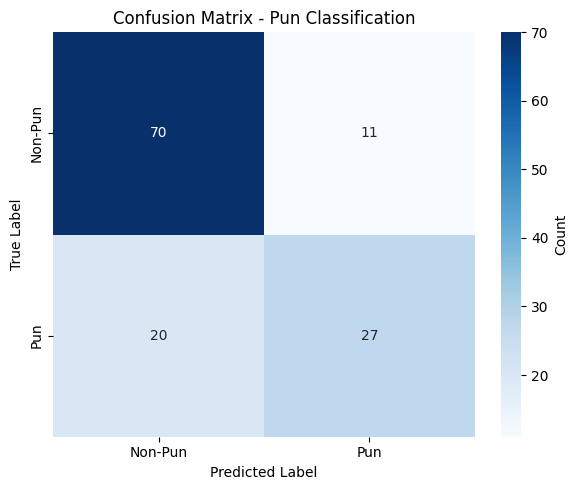


✅ Model training completed!


NameError: name 'output_dir' is not defined

In [ ]:
# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Pun", "Pun"],
            yticklabels=["Non-Pun", "Pun"],
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Pun Classification")
plt.tight_layout()
plt.show()

print("\n✅ Model training completed!")